# 11. 大语言模型架构与 MoE 体系

这一节的目标不是“会调用 API”，而是系统理解现代大语言模型的内部结构：

1. 现代 LLM 为什么大多采用 **Decoder-only Transformer**
2. RoPE、KV Cache、GQA / MQA、SwiGLU、RMSNorm 等结构为什么流行
3. **MoE（Mixture of Experts）** 为什么能让模型在总参数很大时仍保持较低激活成本
4. 当前代表性的开源 / 开放权重大模型家族在架构上到底有什么差异

## 现代大语言模型与 MoE的形式化定义

            现代大语言模型通常指基于大规模自回归预训练的 Decoder-only Transformer 及其变体。其目标是在大规模文本分布上学习条件概率模型：

$$
P(x_1, \dots, x_T)=\prod_{t=1}^{T} P(x_t \mid x_{<t})
$$

MoE 则是在 Transformer 前馈层中引入稀疏专家路由机制的结构变体，其核心目的是在扩大总参数规模的同时控制单 token 的激活计算量。

## 输入、输出与参数化方式

            输入为离散 token 序列，经嵌入和位置编码后进入多层 Transformer Block。每层的注意力子层负责上下文交互，前馈子层负责逐 token 非线性映射。

在 MoE 版本中，标准稠密 FFN 被替换为“路由器 + 多专家前馈网络”的组合。每个 token 只进入少量专家，因此总参数与激活参数分离。

## 结构分解与信息流

            现代 LLM 的关键结构组件通常包括：

- Token Embedding
- Rotary Position Embedding
- Multi-Head / Grouped-Query Attention
- RMSNorm
- SwiGLU 或其他门控前馈层
- KV Cache 友好的推理设计

在 MoE 架构中，注意力层一般保持稠密，而前馈层采用稀疏专家结构，这是因为前馈层通常占据了主要参数量，最适合做稀疏扩容。

## 优化目标与训练机制

            LLM 的核心训练目标仍是最大化序列似然或最小化 next-token cross entropy。MoE 在此基础上额外需要解决负载均衡问题，因此通常引入 auxiliary balancing loss，避免专家使用高度失衡。

这意味着 MoE 的优化并不只是“把总参数做大”，而是同时优化语言建模能力、路由稳定性与分布式训练效率。

## 计算复杂度、统计性质与工程代价

            Dense Transformer 的计算和显存成本对参数和上下文长度都十分敏感。MoE 通过稀疏激活降低了每个 token 的实际计算量，但通信成本上升，系统复杂度也更高。

因此，在评估现代 LLM 架构时，不能只看总参数量，还必须区分：

- 总参数
- 激活参数
- KV Cache 占用
- 训练通信代价
- 推理延迟

## 与相邻模型的差异

            Dense LLM 的结构更直接、推理路径更稳定；MoE LLM 在相同激活预算下可容纳更大容量，但训练和部署更复杂。
相比早期 Transformer，现代 LLM 还增加了大量面向长上下文和推理效率的结构细节，因此“现代 LLM 架构”已经是一整套系统设计，而非单一模块。

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(13, 6))
ax.axis("off")
ax.set_xlim(0, 13)
ax.set_ylim(0, 6)

ax.add_patch(plt.Rectangle((0.8, 2.3), 1.5, 1.2, facecolor="#4C78A8", edgecolor="black"))
ax.text(1.55, 2.9, "Token 表示\nh", ha="center", va="center", fontsize=11)

ax.add_patch(plt.Rectangle((3.2, 2.2), 1.8, 1.4, facecolor="#F58518", edgecolor="black"))
ax.text(4.1, 2.9, "Router\nsoftmax(W_r h)", ha="center", va="center", fontsize=11)

experts = [(7.0, 4.7, "Expert 1"), (7.0, 3.4, "Expert 2"), (7.0, 2.1, "Expert 3"), (7.0, 0.8, "Expert 4")]
for x, y, text in experts:
    ax.add_patch(plt.Rectangle((x - 0.9, y - 0.4), 1.8, 0.8, facecolor="#72B7B2", edgecolor="black"))
    ax.text(x, y, text, ha="center", va="center", fontsize=11)

ax.add_patch(plt.Rectangle((10.7, 2.3), 1.5, 1.2, facecolor="#54A24B", edgecolor="black"))
ax.text(11.45, 2.9, "加权聚合\nΣ p_e E_e(h)", ha="center", va="center", fontsize=11)

ax.annotate("", xy=(3.2, 2.9), xytext=(2.3, 2.9), arrowprops=dict(arrowstyle="->", lw=1.8))
for x, y, _ in experts:
    ax.annotate("", xy=(x - 0.9, y), xytext=(5.0, 2.9), arrowprops=dict(arrowstyle="->", lw=1.2, alpha=0.7))
    ax.annotate("", xy=(10.7, 2.9), xytext=(x + 0.9, y), arrowprops=dict(arrowstyle="->", lw=1.2, alpha=0.7))

ax.text(6.0, 5.6, "Top-k 路由只激活少数专家", fontsize=12)
ax.set_title("MoE 前馈层的稀疏路由结构")
plt.show()

## 先建立直觉

            现代大语言模型可以先粗略理解成“非常非常大的 Transformer”，
但真正重要的是：它们不是简单把参数变大，而是在架构上不断为两个目标服务：

- 提高能力
- 降低推理与训练成本

MoE 的出现正是为了回答一个现实问题：

“如果我想让总参数变大，能不能不要让每个 token 都把所有参数算一遍？”

## 架构是怎么工作的

            现代 LLM 主干大多仍是 Decoder-only Transformer，但细节已经发生了很多变化：

- 位置编码从绝对位置编码转向 RoPE
- 归一化常用 RMSNorm
- FFN 常用 SwiGLU / GeGLU 变体
- 推理时大量依赖 KV Cache
- 为了降低 KV Cache 成本，引入 GQA / MQA
- 为了在总参数更大时保持稀疏计算，引入 MoE

也就是说，现代 LLM 不是“一个点子”，而是一整套为大规模训练与推理服务的架构组合。

## 训练时到底发生了什么

            在 dense 模型里，每个 token 每层都会经过同样的 FFN；
在 MoE 里，每个 token 会先被路由到少数专家，再只经过这些专家。

这样做的好处是：

- 总参数可以很大
- 单次前向的激活参数量却不必同样大

但训练也更复杂：

- 路由是否均衡
- 专家是否都被充分训练
- 分布式通信是否高效

这些问题都不是附属问题，而是 MoE 真正的工程难点。

## 什么时候该用它

            如果你的目标是理解现代 LLM，必须先区分几个概念：

- Dense 和 MoE 的区别
- 总参数和激活参数的区别
- 训练效率和推理效率并不完全相同

学这节时，不要只盯着“参数多少”，更要理解“为什么这样设计”。

## 最常见的误区

            常见误区：

1. **误以为 MoE 就一定比 dense 更强**
   它更像一种容量 / 成本折中方案，不是自动加分项。

2. **误以为总参数越大，推理成本就一定越大**
   对 MoE 来说，关键要看激活参数量。

3. **误以为开源大模型架构差异只是尺寸不同**
   其实在注意力、归一化、专家路由、上下文扩展、推理优化上都有实质差别。

## 1. Decoder-only LLM 的主干结构

现代自回归大语言模型通常按以下顺序堆叠：

1. Token Embedding
2. 位置编码（如 RoPE）
3. 多层 Transformer Block
4. 输出线性层 / LM Head

单个 Transformer Block 常见结构：

$$
h' = h + \mathrm{Attention}(\mathrm{Norm}(h))
$$

$$
h_{out} = h' + \mathrm{FFN}(\mathrm{Norm}(h'))
$$

这就是典型的 **Pre-Norm + Residual** 结构。

## 2. Self-Attention、RoPE、KV Cache、GQA

### Self-Attention

$$
\mathrm{Attention}(Q, K, V)=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

### RoPE（Rotary Position Embedding）

RoPE 的核心思想是：把位置信息编码成对 Query / Key 向量的旋转，使注意力分数天然带有相对位置信息。

### KV Cache

自回归生成时，前面 token 的 Key / Value 不需要每一步都重算，所以会缓存起来：

- 降低推理延迟
- 提高长上下文生成效率

### MQA / GQA

- `MQA`：多个 Query 头共享一组 K/V
- `GQA`：多个 Query 头分组共享 K/V

它们的主要目标是**减少 KV Cache 占用并加快推理**。

## 3. MoE 的核心公式

对于输入 token 表示 $h$，路由器先计算每个专家的分数：

$$
r = W_r h
$$

得到路由概率：

$$
p = \mathrm{softmax}(r)
$$

选择 Top-$k$ 专家后，输出为：

$$
y = \sum_{e \in \mathrm{TopK}(p)} p_e \, E_e(h)
$$

其中：

- $E_e(\cdot)$ 表示第 $e$ 个专家网络
- 每个 token 只激活少数专家，因此**总参数很大，但单次计算成本更低**

这也是 MoE 最核心的“稀疏激活”思想。

## 4. MoE 的关键工程问题

### 路由不均衡

如果大部分 token 都涌向少数专家，会导致：

- 某些专家过载
- 某些专家几乎学不到东西

因此 MoE 训练常加入 **load balancing loss**。

### 容量限制（capacity）

每个专家每个 batch 只接收有限 token，超过容量的 token 需要：

- 丢弃
- 回退到其他专家
- 或者采用更复杂的调度机制

### 通信开销

MoE 在分布式训练中常常比 dense 模型更依赖高效的 All-to-All 通信。

In [ ]:
# 兼容当前 Windows 环境：把临时目录固定到用户目录下的 ASCII 路径，
# 避免 scipy / sklearn 在中文工作目录下寻找临时文件时报错。
from pathlib import Path
import os
import warnings

temp_root = Path(os.environ.get("ML_DL_TMP", str(Path.home() / ".ml_dl_notebook_tmp")))
temp_root.mkdir(exist_ok=True)
os.environ["TMP"] = str(temp_root)
os.environ["TEMP"] = str(temp_root)

warnings.filterwarnings("ignore")

import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
random.seed(42)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)


print("临时目录:", temp_root)

In [ ]:
# 用一个玩具 MoE 层展示“路由到不同专家”的过程。
class ToyMoE(nn.Module):
    def __init__(self, hidden_dim=8, expert_dim=16, num_experts=4, top_k=2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_experts = num_experts
        self.top_k = top_k
        self.router = nn.Linear(hidden_dim, num_experts)
        self.experts = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hidden_dim, expert_dim),
                    nn.ReLU(),
                    nn.Linear(expert_dim, hidden_dim),
                )
                for _ in range(num_experts)
            ]
        )

    def forward(self, x):
        # x: [tokens, hidden_dim]
        logits = self.router(x)
        probs = torch.softmax(logits, dim=-1)
        topk_prob, topk_idx = torch.topk(probs, k=self.top_k, dim=-1)

        output = torch.zeros_like(x)
        for token_id in range(x.size(0)):
            token_out = 0.0
            for prob, expert_id in zip(topk_prob[token_id], topk_idx[token_id]):
                token_out = token_out + prob * self.experts[int(expert_id)](x[token_id : token_id + 1])
            output[token_id : token_id + 1] = token_out
        return output, probs, topk_idx


toy_moe = ToyMoE(hidden_dim=8, expert_dim=16, num_experts=4, top_k=2)
token_batch = torch.randn(24, 8)
output, route_prob, topk_idx = toy_moe(token_batch)

print("输出张量形状:", tuple(output.shape))
print("路由概率形状:", tuple(route_prob.shape))

In [ ]:
# 统计每个专家被选中的次数。
route_counts = []
for expert_id in range(route_prob.size(1)):
    count = int((topk_idx == expert_id).sum().item())
    route_counts.append({"专家": f"Expert {expert_id}", "被选中次数": count})

route_df = pd.DataFrame(route_counts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    route_prob.detach().numpy(),
    cmap="YlGnBu",
    ax=axes[0],
)
axes[0].set_title("每个 token 对各专家的路由概率")
axes[0].set_xlabel("expert")
axes[0].set_ylabel("token")

sns.barplot(data=route_df, x="专家", y="被选中次数", palette="crest", ax=axes[1])
axes[1].set_title("Top-k 路由下各专家的负载")

plt.tight_layout()
plt.show()

## 5. 代表性开源 / 开放权重大模型架构对比

下表基于我核对到的官方公开资料，选取了几类**具有代表性的前沿架构**：

- Dense Decoder-only：Mistral 7B、Llama 3.1 405B
- Sparse MoE：Mixtral 8x7B、DeepSeek-V3、Llama 4 Scout
- 稀疏之外的额外结构创新：例如 DeepSeek-V3 的 MLA、Llama 4 的原生多模态

这些资料对应的官方页面日期包括：

- `2023-12-11`：Mixtral 8x7B 官方发布页
- `2024-12-26`：DeepSeek-V3 官方模型卡
- `2025-04-05`：Llama 4 官方发布页

In [ ]:
llm_df = pd.DataFrame(
    [
        {
            "模型": "Mistral 7B v0.3",
            "发布时间": "2024-05-22",
            "架构": "Dense Decoder-only Transformer",
            "注意力 / 推理优化": "GQA + Sliding Window Attention",
            "FFN / 专家": "Dense MLP",
            "归一化": "RMSNorm",
            "上下文": "32k",
            "总参数": 7,
            "激活参数": 7,
            "是否 MoE": "否",
        },
        {
            "模型": "Mixtral 8x7B v0.1",
            "发布时间": "2023-12-11",
            "架构": "SMoE Decoder-only Transformer",
            "注意力 / 推理优化": "Grouped-Query Attention",
            "FFN / 专家": "8 experts, top-2 routing",
            "归一化": "RMSNorm",
            "上下文": "32k",
            "总参数": 47,
            "激活参数": 13,
            "是否 MoE": "是",
        },
        {
            "模型": "Llama 3.1 405B",
            "发布时间": "2024-07-23",
            "架构": "Dense Decoder-only Transformer",
            "注意力 / 推理优化": "GQA + RoPE",
            "FFN / 专家": "Dense MLP / SwiGLU",
            "归一化": "RMSNorm",
            "上下文": "128k",
            "总参数": 405,
            "激活参数": 405,
            "是否 MoE": "否",
        },
        {
            "模型": "DeepSeek-V3",
            "发布时间": "2024-12-26",
            "架构": "MoE Decoder-only Transformer",
            "注意力 / 推理优化": "MLA + RoPE",
            "FFN / 专家": "671B total, 37B activated",
            "归一化": "RMSNorm",
            "上下文": "128k",
            "总参数": 671,
            "激活参数": 37,
            "是否 MoE": "是",
        },
        {
            "模型": "Llama 4 Scout",
            "发布时间": "2025-04-05",
            "架构": "Native Multimodal MoE",
            "注意力 / 推理优化": "MoE + 长上下文设计",
            "FFN / 专家": "16 experts, 17B active / 109B total",
            "归一化": "官方未强调变化，保留 Transformer 族设计",
            "上下文": "10M",
            "总参数": 109,
            "激活参数": 17,
            "是否 MoE": "是",
        },
    ]
)

llm_df

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_df = llm_df.copy()
sns.scatterplot(
    data=plot_df,
    x="总参数",
    y="激活参数",
    hue="是否 MoE",
    style="是否 MoE",
    s=220,
    ax=axes[0],
)
for _, row in plot_df.iterrows():
    axes[0].text(row["总参数"] + 4, row["激活参数"] + 2, row["模型"], fontsize=10)
axes[0].set_title("总参数 vs 激活参数")

moe_ratio = plot_df.assign(激活占比=plot_df["激活参数"] / plot_df["总参数"])
sns.barplot(data=moe_ratio, x="模型", y="激活占比", palette="viridis", ax=axes[1])
axes[1].set_title("不同模型的激活参数占比")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 6. 架构差异该如何理解

### Dense 模型

- 优点：训练和推理实现更直接，通信模式更简单
- 缺点：如果参数继续增大，推理成本线性增加

### MoE 模型

- 优点：在保持较低激活成本的前提下扩大总参数容量
- 缺点：路由、负载均衡、专家并行和通信实现更复杂

### 为什么现代 LLM 越来越重视 GQA / KV Cache / 长上下文

原因很直接：真实应用的瓶颈往往不是训练 FLOPs，而是**推理延迟、显存占用和长上下文效率**。

## 7. 官方资料链接

- Llama 4 官方发布页: https://ai.meta.com/blog/llama-4-multimodal-intelligence/
- Llama 3.1 官方发布页: https://ai.meta.com/blog/meta-llama-3-1/
- Mixtral 8x7B 官方发布页: https://mistral.ai/news/mixtral-of-experts/
- Mistral 7B 官方文档: https://docs.mistral.ai/getting-started/models/models_overview/
- DeepSeek-V3 官方模型卡: https://huggingface.co/deepseek-ai/DeepSeek-V3

## 8.补充说明——Engram模块
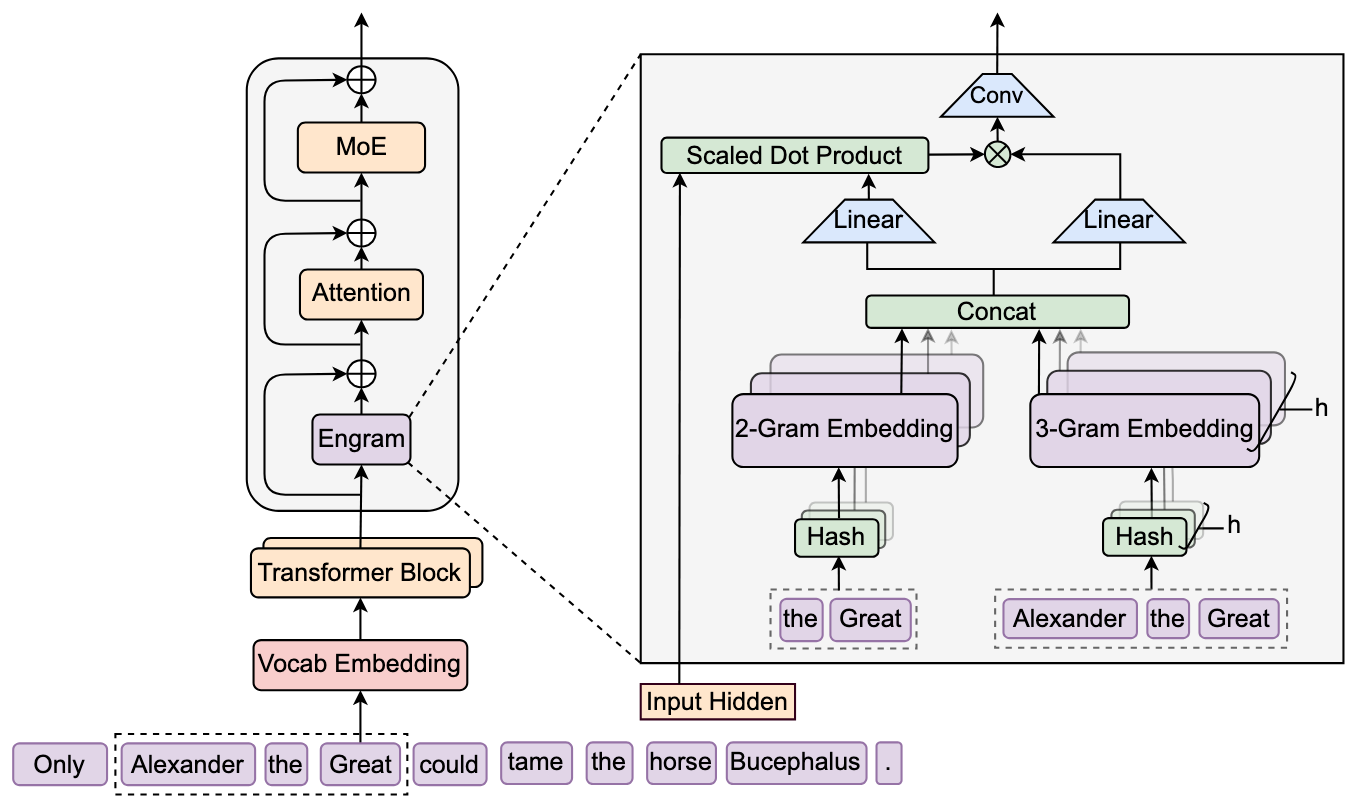

In [2]:
from typing import List
from dataclasses import dataclass, field
import math

## third-party
from sympy import isprime
import numpy as np
import torch
import torch.nn as nn
from transformers import AutoTokenizer
from tokenizers import normalizers, Regex 

In [3]:
@dataclass
class EngramConfig:
    tokenizer_name_or_path: str = "deepseek-ai/DeepSeek-V3"
    engram_vocab_size: List[int] = field(default_factory=lambda: [129280*5, 129280*5])
    max_ngram_size: int = 3
    n_embed_per_ngram: int = 512
    n_head_per_ngram: int = 8
    layer_ids: List[int] = field(default_factory=lambda: [1, 15])
    pad_id: int = 2
    seed: int = 0
    kernel_size: int = 4
    
@dataclass
class BackBoneConfig:
    hidden_size: int = 1024
    hc_mult: int = 4
    vocab_size: int = 129280
    num_layers: int = 30
    
engram_cfg = EngramConfig()
backbone_config = BackBoneConfig()

In [4]:
class CompressedTokenizer:
    def __init__(
        self,
        tokenizer_name_or_path,
    ):
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name_or_path, trust_remote_code=True)
        
        SENTINEL = "\uE000"
        self.normalizer = normalizers.Sequence([
            normalizers.NFKC(),
            normalizers.NFD(),
            normalizers.StripAccents(),
            normalizers.Lowercase(),
            normalizers.Replace(Regex(r"[ \t\r\n]+"), " "),
            normalizers.Replace(Regex(r"^ $"), SENTINEL),
            normalizers.Strip(),
            normalizers.Replace(SENTINEL, " "),
        ])
        
        self.lookup_table, self.num_new_token = self._build_lookup_table()
    
    def __len__(self):
        return self.num_new_token
    
    def _build_lookup_table(self):
        old2new = {}
        key2new = {}          
        new_tokens = []

        vocab_size = len(self.tokenizer)
        for tid in range(vocab_size):
            text = self.tokenizer.decode([tid], skip_special_tokens=False)
            
            if "�" in text:
                key = self.tokenizer.convert_ids_to_tokens(tid)
            else:
                norm = self.normalizer.normalize_str(text)
                key = norm if norm else text

            nid = key2new.get(key)
            if nid is None:
                nid = len(new_tokens)
                key2new[key] = nid
                new_tokens.append(key)
            old2new[tid] = nid
        
        lookup = np.empty(vocab_size, dtype=np.int64)
        for tid in range(vocab_size):
            lookup[tid] = old2new[tid]

        return lookup, len(new_tokens)
    
    def _compress(self, input_ids):
        arr = np.asarray(input_ids, dtype=np.int64)
        pos_mask = arr >= 0
        out = arr.copy()
        valid_ids = arr[pos_mask]
        out[pos_mask] = self.lookup_table[valid_ids]
        return out   
    
    def __call__(self, input_ids):
        return self._compress(input_ids)

In [5]:
class ShortConv(nn.Module):
    def __init__(
        self, 
        hidden_size: int, 
        kernel_size: int = 4, 
        dilation: int = 1, 
        norm_eps: float = 1e-5,
        hc_mult: int = 4,
        activation: bool = True,
    ):
        super().__init__()
        self.hc_mult = hc_mult
        self.activation = activation
        
        total_channels = hidden_size * hc_mult
        self.conv = nn.Conv1d(
            in_channels=total_channels,
            out_channels=total_channels,
            kernel_size=kernel_size,
            groups=total_channels,
            bias=False,
            padding=(kernel_size - 1) * dilation,
            dilation=dilation,
        )

        self.norms = nn.ModuleList([
            nn.RMSNorm(hidden_size, eps=norm_eps) 
            for _ in range(hc_mult)
        ])
        
        if self.activation:
            self.act_fn = nn.SiLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Input:  (B,L,HC_MULT,D)
        Output: (B,L,HC_MULT,D)
        """
        B, T, G, C = x.shape
        
        assert G == self.hc_mult, f"Input groups {G} != hc_mult {self.hc_mult}"

        normed_chunks = []
        for i in range(G):
            chunk = x[:, :, i, :]
            normed_chunks.append(self.norms[i](chunk))
        
        x_norm = torch.cat(normed_chunks, dim=-1)
        x_bct = x_norm.transpose(1, 2)
        y_bct = self.conv(x_bct)
        y_bct = y_bct[..., :T]

        if self.activation:
            y_bct = self.act_fn(y_bct)
        y = y_bct.transpose(1, 2).view(B, T, G, C).contiguous()
        
        return y
    
def find_next_prime(start, seen_primes):
    candidate = start + 1
    while True:
        if isprime(candidate) and candidate not in seen_primes:
            return candidate
        candidate += 1

In [6]:
class NgramHashMapping:
    def __init__(
        self, 
        engram_vocab_size,
        max_ngram_size,
        n_embed_per_ngram,
        n_head_per_ngram,
        layer_ids,
        tokenizer_name_or_path,
        pad_id,
        seed,  
    ):
        self.vocab_size_per_ngram = engram_vocab_size
        self.max_ngram_size = max_ngram_size
        self.n_embed_per_ngram = n_embed_per_ngram
        self.n_head_per_ngram = n_head_per_ngram
        self.pad_id = pad_id
        self.layer_ids = layer_ids

        self.compressed_tokenizer = CompressedTokenizer(
            tokenizer_name_or_path=tokenizer_name_or_path
        )            
        self.tokenizer_vocab_size = len(self.compressed_tokenizer)
        if self.pad_id is not None:
            self.pad_id = int(self.compressed_tokenizer.lookup_table[self.pad_id])

        max_long = np.iinfo(np.int64).max
        M_max = int(max_long // self.tokenizer_vocab_size)
        half_bound = max(1, M_max // 2)
        PRIME_1 = 10007
        
        self.layer_multipliers = {}

        for layer_id in self.layer_ids:
            base_seed = int(seed + PRIME_1 * int(layer_id))
            g = np.random.default_rng(base_seed)
            r = g.integers(
                low=0,
                high=half_bound,
                size=(self.max_ngram_size,),
                dtype=np.int64
            )
            multipliers = r * 2 + 1
            self.layer_multipliers[layer_id] = multipliers

        self.vocab_size_across_layers = self.calculate_vocab_size_across_layers()

    def calculate_vocab_size_across_layers(self):
        seen_primes = set()
        vocab_size_across_layers = {}
        
        for layer_id in self.layer_ids:
            all_ngram_vocab_sizes = []
            for ngram in range(2, self.max_ngram_size + 1):
                current_ngram_heads_sizes = []
                
                vocab_size = self.vocab_size_per_ngram[ngram - 2]
                num_head = self.n_head_per_ngram
                current_prime_search_start = vocab_size - 1
                
                for _ in range(num_head):
                    found_prime = find_next_prime(
                        current_prime_search_start, 
                        seen_primes
                    )
                    seen_primes.add(found_prime)
                    current_ngram_heads_sizes.append(found_prime)
                    current_prime_search_start = found_prime
                
                all_ngram_vocab_sizes.append(current_ngram_heads_sizes)
            vocab_size_across_layers[layer_id] = all_ngram_vocab_sizes
            
        return vocab_size_across_layers

    def _get_ngram_hashes(
        self,
        input_ids: np.ndarray,
        layer_id: int,
    ) -> np.ndarray:
        x = np.asarray(input_ids, dtype=np.int64)
        B, T = x.shape

        multipliers = self.layer_multipliers[layer_id]

        def shift_k(k: int) -> np.ndarray:
            if k == 0: return x
            shifted = np.pad(x, ((0, 0), (k, 0)),
                                mode='constant', constant_values=self.pad_id)[:, :T]
            return shifted

        base_shifts = [shift_k(k) for k in range(self.max_ngram_size)]

        all_hashes = []
        
        for n in range(2, self.max_ngram_size + 1):
            n_gram_index = n - 2
            tokens = base_shifts[:n]
            mix = (tokens[0] * multipliers[0])
            for k in range(1, n):
                mix = np.bitwise_xor(mix, tokens[k] * multipliers[k])
            num_heads_for_this_ngram = self.n_head_per_ngram
            head_vocab_sizes = self.vocab_size_across_layers[layer_id][n_gram_index]
            
            for j in range(num_heads_for_this_ngram):
                mod = int(head_vocab_sizes[j])
                head_hash = mix % mod
                all_hashes.append(head_hash.astype(np.int64, copy=False))
        
        return np.stack(all_hashes, axis=2)

    def hash(self, input_ids):
        input_ids = self.compressed_tokenizer(input_ids)
        hash_ids_for_all_layers = {}
        for layer_id in self.layer_ids:
            hash_ids_for_all_layers[layer_id] = self._get_ngram_hashes(input_ids, layer_id=layer_id)
        return hash_ids_for_all_layers

In [7]:
class MultiHeadEmbedding(nn.Module):
    def __init__(self, list_of_N: List[int], D: int):
        super().__init__()
        self.num_heads = len(list_of_N)
        self.embedding_dim = D
        
        offsets = [0]
        for n in list_of_N[:-1]:
            offsets.append(offsets[-1] + n)
        
        self.register_buffer("offsets", torch.tensor(offsets, dtype=torch.long))
        
        total_N = sum(list_of_N)
        self.embedding = nn.Embedding(num_embeddings=total_N, embedding_dim=D)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        shifted_input_ids = input_ids + self.offsets
        output = self.embedding(shifted_input_ids)
        
        return output
    
class Engram(nn.Module):
    def __init__(self, layer_id):
        super().__init__()
        self.layer_id = layer_id
        self.hash_mapping = NgramHashMapping(
            engram_vocab_size=engram_cfg.engram_vocab_size,
            max_ngram_size = engram_cfg.max_ngram_size,
            n_embed_per_ngram = engram_cfg.n_embed_per_ngram,
            n_head_per_ngram = engram_cfg.n_head_per_ngram,
            layer_ids = engram_cfg.layer_ids,
            tokenizer_name_or_path=engram_cfg.tokenizer_name_or_path,
            pad_id = engram_cfg.pad_id,
            seed = engram_cfg.seed,
        )
        self.multi_head_embedding = MultiHeadEmbedding(
            list_of_N = [x for y in self.hash_mapping.vocab_size_across_layers[self.layer_id] for x in y],
            D = engram_cfg.n_embed_per_ngram // engram_cfg.n_head_per_ngram,
        )
        self.short_conv = ShortConv(
            hidden_size = backbone_config.hidden_size,
            kernel_size = engram_cfg.kernel_size,
            dilation    = engram_cfg.max_ngram_size,
            hc_mult     = backbone_config.hc_mult,
        )
        engram_hidden_size = (engram_cfg.max_ngram_size-1) * engram_cfg.n_embed_per_ngram
        self.value_proj = nn.Linear(engram_hidden_size,backbone_config.hidden_size)
        self.key_projs = nn.ModuleList(
            [nn.Linear(engram_hidden_size,backbone_config.hidden_size) for _ in range(backbone_config.hc_mult)]
        )
        self.norm1 = nn.ModuleList([nn.RMSNorm(backbone_config.hidden_size) for _ in range(backbone_config.hc_mult)])
        self.norm2 = nn.ModuleList([nn.RMSNorm(backbone_config.hidden_size) for _ in range(backbone_config.hc_mult)])
    
    def forward(self,hidden_states,input_ids):
        """
        hidden_states: [B, L, HC_MULT, D]
        input_ids: [B, L]
        """
        hash_input_ids = torch.from_numpy(self.hash_mapping.hash(input_ids)[self.layer_id])
        embeddings = self.multi_head_embedding(hash_input_ids).flatten(start_dim=-2)
        gates = []
        for hc_idx in range(backbone_config.hc_mult):
            key = self.key_projs[hc_idx](embeddings)
            normed_key = self.norm1[hc_idx](key)
            query = hidden_states[:,:,hc_idx,:]
            normed_query = self.norm2[hc_idx](query)
            gate = (normed_key * normed_query).sum(dim=-1) / math.sqrt(backbone_config.hidden_size)
            gate = gate.abs().clamp_min(1e-6).sqrt() * gate.sign()
            gate = gate.sigmoid().unsqueeze(-1)
            gates.append(gate)
        gates = torch.stack(gates,dim=2)
        value = gates * self.value_proj(embeddings).unsqueeze(2)
        output = value + self.short_conv(value)
        return output 

class TransformerBlock(nn.Module):
    def __init__(self,layer_id):
        super().__init__()
        self.attn = lambda x:x
        self.moe  = lambda x:x
        self.engram = None
        if layer_id in engram_cfg.layer_ids:
            self.engram = Engram(layer_id=layer_id)
    
    def forward(self,input_ids,hidden_states):
        if self.engram is not None:
            hidden_states = self.engram(hidden_states=hidden_states,input_ids=input_ids) + hidden_states
        hidden_states = self.attn(hidden_states) + hidden_states
        hidden_states = self.moe(hidden_states) + hidden_states
        return hidden_states

In [8]:
LLM = [
    nn.Embedding(backbone_config.vocab_size,backbone_config.hidden_size),
    *[TransformerBlock(layer_id=layer_id) for layer_id in range(backbone_config.num_layers)],
    nn.Linear(backbone_config.hidden_size, backbone_config.vocab_size)
]

text = "Only Alexander the Great could tame the horse Bucephalus."
tokenizer = AutoTokenizer.from_pretrained(engram_cfg.tokenizer_name_or_path,trust_remote_code=True)
input_ids = tokenizer(text,return_tensors='pt').input_ids

B,L = input_ids.shape

for idx, layer in enumerate(LLM):
    if idx == 0:
        hidden_states = LLM[0](input_ids)
        ## mock hyper-connection
        hidden_states = hidden_states.unsqueeze(2).expand(-1, -1, backbone_config.hc_mult, -1)      
    elif idx == len(LLM)-1:
        ## mock hyper-connection
        hidden_states = hidden_states[:,:,0,:] 
        output = layer(hidden_states)
    else:
        hidden_states = layer(input_ids=input_ids,hidden_states=hidden_states)

print("✅ Forward Complete!")
print(f"{input_ids.shape=}\n{output.shape=}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

C:\Users\41424\AppData\Roaming\Python\Python310\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\41424\.cache\huggingface\hub\models--deepseek-ai--DeepSeek-V3. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer.json: 0.00B [00:00, ?B/s]

✅ Forward Complete!
input_ids.shape=torch.Size([1, 14])
output.shape=torch.Size([1, 14, 129280])
